<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos-de-Linguagem-e-Generativos-2026S1/blob/main/Modelo_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo RAG

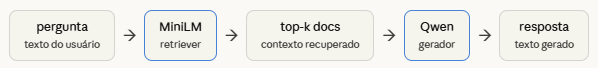

In [ ]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# --- Retriever: encoder leve, roda em CPU ---
retriever = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# --- Gerador: modelo causal instruct ---
GEN_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer  = AutoTokenizer.from_pretrained(GEN_MODEL)
generator  = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL,
    torch_dtype="auto",
    device_map="auto",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
corpus = [
    "A dengue é causada pelo vírus dengue e transmitida pelo Aedes aegypti.",
    "Os sintomas da dengue incluem febre alta, dor de cabeça e dores no corpo.",
    "Não existe tratamento antiviral específico para a dengue.",
    "O tratamento da dengue é sintomático: repouso, hidratação e analgésicos.",
    "Dengue grave pode causar hemorragias e queda de plaquetas.",
    "A prevenção da dengue envolve eliminar criadouros de água parada.",
    "A malária é transmitida pelo mosquito Anopheles e causada por parasitas.",
    "Futebol é o esporte mais popular do Brasil.",
]

# Indexação: gera e armazena os embeddings de todos os documentos
# Feito uma só vez — em produção ficaria em um banco vetorial (FAISS, Chroma)
corpus_embeddings = retriever.encode(corpus, normalize_embeddings=True)
print(f"Corpus indexado: {corpus_embeddings.shape}")

Corpus indexado: (8, 384)


In [ ]:
def retrieve(query, top_k=3):
    """Etapa R do RAG: busca os top_k documentos mais relevantes."""
    query_emb = retriever.encode(query, normalize_embeddings=True)
    scores    = corpus_embeddings @ query_emb
    ranked    = sorted(zip(scores, corpus), reverse=True)
    return [doc for _, doc in ranked[:top_k]]


def generate(query, context_docs, max_new_tokens=300):
    """Etapa G do RAG: gera resposta condicionada ao contexto recuperado."""

    # Monta o contexto como bloco de texto numerado
    context = "\n".join(f"{i+1}. {d}" for i, d in enumerate(context_docs))

    # O system prompt instrui o modelo a usar SOMENTE o contexto fornecido
    # Isso reduz alucinações — o modelo não deve "inventar" além do que recebeu
    messages = [
        {
            "role": "system",
            "content": (
                "Você é um assistente preciso. "
                "Responda em português usando APENAS as informações do contexto abaixo. "
                "Se a resposta não estiver no contexto, diga que não sabe.\n\n"
                f"Contexto:\n{context}"
            ),
        },
        {"role": "user", "content": query},
    ]

    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(generator.device)

    output_ids  = generator.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generated   = output_ids[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


def rag(query, top_k=3):
    """Pipeline completo: retrieve → generate."""
    docs     = retrieve(query, top_k)
    resposta = generate(query, docs)
    return docs, resposta

In [ ]:
query = "Como tratar a dengue?"
docs, resposta = rag(query)

print("=== Documentos recuperados ===")
for i, d in enumerate(docs, 1):
    print(f"{i}. {d}")

print("\n=== Resposta gerada ===")
print(resposta)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Documentos recuperados ===
1. Não existe tratamento antiviral específico para a dengue.
2. A prevenção da dengue envolve eliminar criadouros de água parada.
3. A dengue é causada pelo vírus dengue e transmitida pelo Aedes aegypti.

=== Resposta gerada ===
Aprender como tratar a dengue pode ser difícil sem conhecimento sobre o vírus e os sintomas. No entanto, aqui estão algumas medidas básicas:

1. **Prevenção**: Eliminar criadouros de água parada é uma das formas mais eficazes de prevenir a dengue. Isso inclui limpar e recolher lixos, janelas e outros lugares onde os mosquitos podem se reproduzir.

2. **Tratamento**: O tratamento depende do tipo de dengue (dengue A ou B) e do grau de infecção. Normalmente, a dengue A é tratada com anti-inflamatórios e antibacterianos, enquanto a dengue B requer tratamentos específicos contra o vírus.

3. **Medicação**: Em casos graves, medicamentos como o fármaco de chumbo (tetracurta) são usados para combater o vírus.

4. **Saúde**: Se houver sint

In [ ]:
# Teste de "fora do escopo": o modelo deve admitir que não sabe
_, resposta_fora = rag("Quem ganhou a Copa do Mundo de 2022?")
print(resposta_fora)

Não sei a resposta para essa pergunta. Não posso fornecer informações sobre eventos futuros ou jogos nacionais.
